# Week 5 — Training Pathologies: Why PINNs Fail & How to Fix Them
> **Goal:** Implement Fourier feature embedding and gradient-norm loss balancing on the Week 4 Burgers PINN, and compare all three variants head-to-head.

**Baseline problem (same as Week 4):**
```
uₜ + u·uₓ = (ν/π)·uₓₓ,   x ∈ [−1, 1],  t ∈ [0, 1]
u(−1,t)=0, u(1,t)=0,  u(x,0)=−sin(πx),  ν = 0.01/π
```


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.fft import fft, ifft

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


---
## Reference Solution (same spectral solver as Week 4)

In [2]:
def burgers_exact_spectral(x_grid, t_eval, nu=0.01/np.pi, N=512):
    x_spec = np.linspace(-1, 1, N, endpoint=False)
    dx = x_spec[1] - x_spec[0]
    k = np.fft.fftfreq(N, d=dx / (2 * np.pi))
    u0 = -np.sin(np.pi * x_spec)

    def rhs(t, u_hat):
        u = np.real(ifft(u_hat))
        u_x = np.real(ifft(1j * k * u_hat))
        nonlin = -u * u_x
        diff = -nu * k**2 * u_hat
        return fft(nonlin) + diff

    u0_hat = fft(u0)
    sol = solve_ivp(rhs, [0, 1], u0_hat, t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-10)
    result = np.zeros((len(t_eval), len(x_grid)))
    for i, u_hat_t in enumerate(sol.y.T):
        u_spec = np.real(ifft(u_hat_t))
        result[i] = np.interp(x_grid, x_spec, u_spec)
    return result

x_eval = np.linspace(-1, 1, 256)
t_eval = np.linspace(0, 1, 100)
print("Computing reference solution...")
u_exact = burgers_exact_spectral(x_eval, t_eval)
print(f"Reference shape: {u_exact.shape}")

nu = 0.01 / np.pi

Computing reference solution...
Reference shape: (100, 256)


---
## Shared Utilities — sampling, PDE residual, evaluation

In [3]:
def sample_points(n_interior=10000, n_bc=200, n_ic=100):
    x_int = torch.rand(n_interior, 1) * 2 - 1
    t_int = torch.rand(n_interior, 1)
    xt_int = torch.cat([x_int, t_int], dim=1).to(DEVICE).requires_grad_(True)

    t_bc = torch.rand(n_bc, 1)
    x_left = -torch.ones(n_bc // 2, 1)
    x_right = torch.ones(n_bc // 2, 1)
    xt_bc_L = torch.cat([x_left, t_bc[:n_bc//2]], dim=1).to(DEVICE)
    xt_bc_R = torch.cat([x_right, t_bc[n_bc//2:]], dim=1).to(DEVICE)

    x_ic = torch.rand(n_ic, 1) * 2 - 1
    t_ic = torch.zeros(n_ic, 1)
    xt_ic = torch.cat([x_ic, t_ic], dim=1).to(DEVICE)
    u_ic = -torch.sin(np.pi * x_ic).to(DEVICE)

    return xt_int, xt_bc_L, xt_bc_R, xt_ic, u_ic


def pde_residual(model, xt):
    xt = xt.requires_grad_(True)
    u = model(xt)
    u_grad = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]
    u_t = u_grad[:, 1:2]
    u_x = u_grad[:, 0:1]
    u_xx = torch.autograd.grad(u_x.sum(), xt, create_graph=True)[0][:, 0:1]
    return u_t + u * u_x - (nu / np.pi) * u_xx


def eval_model(model, x_grid, t_grid):
    X, T = np.meshgrid(x_grid, t_grid)
    XT = np.column_stack([X.ravel(), T.ravel()])
    xt_t = torch.tensor(XT, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        u = model(xt_t).cpu().numpy().reshape(len(t_grid), len(x_grid))
    return u


def l2_relative_error(pred, true):
    return np.sqrt(np.mean((pred - true)**2)) / (np.sqrt(np.mean(true**2)) + 1e-10)

print("Utilities defined ✓")

Utilities defined ✓


---
## Variant 1 — Vanilla Baseline PINN (Week 4 recap)

In [4]:
class VanillaPINN(nn.Module):
    def __init__(self, hidden=100, layers=4):
        super().__init__()
        net = [nn.Linear(2, hidden), nn.Tanh()]
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, xt):
        return self.net(xt)

print("VanillaPINN defined ✓")

VanillaPINN defined ✓


---
## Task 1 — Fourier Feature Embedding

Instead of feeding `(x,t)` directly, we project through a random Fourier basis:

```
γ(v) = [sin(Bv), cos(Bv)]      where B ~ N(0, σ²), B has shape (d, 2)
```

This explicitly gives the network access to higher-frequency modes, countering spectral bias.
`d = 128` → embedding dimension = 256 (128 sin + 128 cos).

In [5]:
class FourierPINN(nn.Module):
    """
    PINN with Fourier feature input embedding.
    Input (x,t) -> [sin(Bv), cos(Bv)] -> MLP -> u
    """
    def __init__(self, hidden=100, layers=4, d=128, sigma=10.0):
        super().__init__()
        # Fixed (non-trainable) random Fourier matrix
        B = torch.randn(d, 2) * sigma
        self.register_buffer("B", B)   # moves with .to(device), not trained

        net = [nn.Linear(2 * d, hidden), nn.Tanh()]   # 2*d = sin+cos concatenated
        for _ in range(layers - 2):
            net += [nn.Linear(hidden, hidden), nn.Tanh()]
        net += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*net)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def fourier_embed(self, xt):
        proj = xt @ self.B.T                 # (N, d)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (N, 2d)

    def forward(self, xt):
        emb = self.fourier_embed(xt)
        return self.net(emb)

print("FourierPINN defined ✓")
print(f"Embedding dim for d=128: {2*128} = 256 features")

FourierPINN defined ✓
Embedding dim for d=128: 256 = 256 features


---
## Task 2 — Gradient-Norm Loss Balancing (Wang, Teng, Perdikaris 2021)

At each step, compute the gradient norm of each loss term w.r.t. the network weights. Rescale
`λ_bc`, `λ_ic` so all three terms contribute equally to the total gradient magnitude.

```
mean_grad = (‖∇L_pde‖ + ‖∇L_bc‖ + ‖∇L_ic‖) / 3
λ_bc = mean_grad / ‖∇L_bc‖
λ_ic = mean_grad / ‖∇L_ic‖
```


In [6]:
def gradient_norm(loss, params):
    """Compute the L2 norm of the gradient of `loss` w.r.t. `params`."""
    grads = torch.autograd.grad(loss, params, retain_graph=True, create_graph=False, allow_unused=True)
    total = 0.0
    for g in grads:
        if g is not None:
            total += g.pow(2).sum().item()
    return np.sqrt(total) + 1e-8


def train_gradnorm_balanced(model, epochs=10000, lr=1e-3, update_every=1,
                             n_interior=10000, n_bc=200, n_ic=100, label="GradNorm Balanced"):
    """
    Train with adaptive lambda_bc, lambda_ic recomputed from gradient norms.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)
    xt_int, xt_bc_L, xt_bc_R, xt_ic, u_ic = sample_points(n_interior, n_bc, n_ic)
    params = list(model.parameters())

    lambda_bc, lambda_ic = 1.0, 1.0
    losses = {"total": [], "pde": [], "bc": [], "ic": [], "lambda_bc": [], "lambda_ic": []}

    print(f"Training [{label}]  {epochs} epochs ...")
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        res = pde_residual(model, xt_int)
        L_pde = (res**2).mean()

        u_left = model(xt_bc_L)
        u_right = model(xt_bc_R)
        L_bc = (u_left**2).mean() + (u_right**2).mean()

        u_ic_pred = model(xt_ic)
        L_ic = ((u_ic_pred - u_ic)**2).mean()

        # ── Recompute lambda via gradient norms every `update_every` steps ──────
        if epoch % update_every == 0:
            g_pde = gradient_norm(L_pde, params)
            g_bc  = gradient_norm(L_bc,  params)
            g_ic  = gradient_norm(L_ic,  params)
            mean_grad = (g_pde + g_bc + g_ic) / 3
            lambda_bc = mean_grad / g_bc
            lambda_ic = mean_grad / g_ic

        loss = L_pde + lambda_bc * L_bc + lambda_ic * L_ic
        loss.backward()
        optimizer.step()
        scheduler.step()

        losses["total"].append(loss.item())
        losses["pde"].append(L_pde.item())
        losses["bc"].append(L_bc.item())
        losses["ic"].append(L_ic.item())
        losses["lambda_bc"].append(lambda_bc)
        losses["lambda_ic"].append(lambda_ic)

        if epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Total={loss.item():.3e} | "
                  f"λ_bc={lambda_bc:.2f} λ_ic={lambda_ic:.2f}")

    return losses

print("Gradient-norm balancing functions defined ✓")

Gradient-norm balancing functions defined ✓


---
## Task 3 — Comparative Experiment

Train all three variants on the identical Burgers' setup.

In [7]:
def train_standard(model, epochs=10000, lr=1e-3, lambda_bc=10.0, lambda_ic=10.0,
                    n_interior=10000, n_bc=200, n_ic=100, label="Vanilla"):
    """Standard fixed-weight training (used for Vanilla and Fourier variants)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)
    xt_int, xt_bc_L, xt_bc_R, xt_ic, u_ic = sample_points(n_interior, n_bc, n_ic)

    losses = {"total": [], "pde": [], "bc": [], "ic": []}
    print(f"Training [{label}]  {epochs} epochs ...")
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        res = pde_residual(model, xt_int)
        L_pde = (res**2).mean()
        u_left, u_right = model(xt_bc_L), model(xt_bc_R)
        L_bc = (u_left**2).mean() + (u_right**2).mean()
        u_ic_pred = model(xt_ic)
        L_ic = ((u_ic_pred - u_ic)**2).mean()
        loss = L_pde + lambda_bc * L_bc + lambda_ic * L_ic
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses["total"].append(loss.item())
        losses["pde"].append(L_pde.item())
        losses["bc"].append(L_bc.item())
        losses["ic"].append(L_ic.item())
        if epoch % 2000 == 0:
            print(f"  Epoch {epoch:5d} | Total={loss.item():.3e}")
    return losses


# ── Variant 1: Vanilla PINN ───────────────────────────────────────────────────
model_vanilla = VanillaPINN(hidden=100, layers=4).to(DEVICE)
losses_vanilla = train_standard(model_vanilla, epochs=10000, label="1. Vanilla PINN")

# ── Variant 2: Vanilla + Fourier Features (sigma=10) ─────────────────────────
model_fourier = FourierPINN(hidden=100, layers=4, d=128, sigma=10.0).to(DEVICE)
losses_fourier = train_standard(model_fourier, epochs=10000, label="2. Fourier Features (σ=10)")

# ── Variant 3: Vanilla + Gradient-Norm Balancing ─────────────────────────────
model_gradnorm = VanillaPINN(hidden=100, layers=4).to(DEVICE)
losses_gradnorm = train_gradnorm_balanced(model_gradnorm, epochs=10000, update_every=1,
                                           label="3. Gradient-Norm Balancing")

print("\nAll three variants trained ✓")

Training [1. Vanilla PINN]  10000 epochs ...
  Epoch  2000 | Total=2.537e-01
  Epoch  4000 | Total=2.272e-01
  Epoch  6000 | Total=2.100e-01
  Epoch  8000 | Total=1.973e-01
  Epoch 10000 | Total=1.825e-01
Training [2. Fourier Features (σ=10)]  10000 epochs ...
  Epoch  2000 | Total=5.328e-02
  Epoch  4000 | Total=6.120e-03
  Epoch  6000 | Total=1.773e-03
  Epoch  8000 | Total=1.364e-03
  Epoch 10000 | Total=5.198e-04
Training [3. Gradient-Norm Balancing]  10000 epochs ...
  Epoch  2000 | Total=6.419e-02 | λ_bc=5.36 λ_ic=0.54
  Epoch  4000 | Total=5.527e-02 | λ_bc=7.03 λ_ic=0.57
  Epoch  6000 | Total=5.053e-02 | λ_bc=1.74 λ_ic=0.60
  Epoch  8000 | Total=6.106e-02 | λ_bc=1.48 λ_ic=0.88
  Epoch 10000 | Total=4.919e-02 | λ_bc=3.42 λ_ic=0.70

All three variants trained ✓


### Also train σ=1 Fourier variant (for Question 1 analysis)

In [8]:
model_fourier_s1 = FourierPINN(hidden=100, layers=4, d=128, sigma=1.0).to(DEVICE)
losses_fourier_s1 = train_standard(model_fourier_s1, epochs=10000, label="Fourier Features (σ=1)")
print("σ=1 variant trained ✓")

Training [Fourier Features (σ=1)]  10000 epochs ...
  Epoch  2000 | Total=1.978e-01
  Epoch  4000 | Total=1.600e-01
  Epoch  6000 | Total=1.920e-02
  Epoch  8000 | Total=1.485e-01
  Epoch 10000 | Total=5.112e-02
σ=1 variant trained ✓


### Evaluate all variants against the reference solution

In [9]:
u_vanilla  = eval_model(model_vanilla,  x_eval, t_eval)
u_fourier  = eval_model(model_fourier,  x_eval, t_eval)
u_gradnorm = eval_model(model_gradnorm, x_eval, t_eval)
u_fourier1 = eval_model(model_fourier_s1, x_eval, t_eval)

l2_vanilla  = l2_relative_error(u_vanilla,  u_exact)
l2_fourier  = l2_relative_error(u_fourier,  u_exact)
l2_gradnorm = l2_relative_error(u_gradnorm, u_exact)
l2_fourier1 = l2_relative_error(u_fourier1, u_exact)

print("┌─────────────────────────────────┬──────────────────┐")
print("│ Variant                         │  L² Rel. Error   │")
print("├─────────────────────────────────┼──────────────────┤")
print(f"│ 1. Vanilla PINN                 │   {l2_vanilla:.4e}    │")
print(f"│ 2. Fourier Features (σ=10)      │   {l2_fourier:.4e}    │")
print(f"│ 2b. Fourier Features (σ=1)      │   {l2_fourier1:.4e}    │")
print(f"│ 3. Gradient-Norm Balancing      │   {l2_gradnorm:.4e}    │")
print("└─────────────────────────────────┴──────────────────┘")

┌─────────────────────────────────┬──────────────────┐
│ Variant                         │  L² Rel. Error   │
├─────────────────────────────────┼──────────────────┤
│ 1. Vanilla PINN                 │   3.0679e-01    │
│ 2. Fourier Features (σ=10)      │   3.0126e-01    │
│ 2b. Fourier Features (σ=1)      │   1.0523e-01    │
│ 3. Gradient-Norm Balancing      │   4.3405e-01    │
└─────────────────────────────────┴──────────────────┘


### Comparison Figure — All Loss Curves

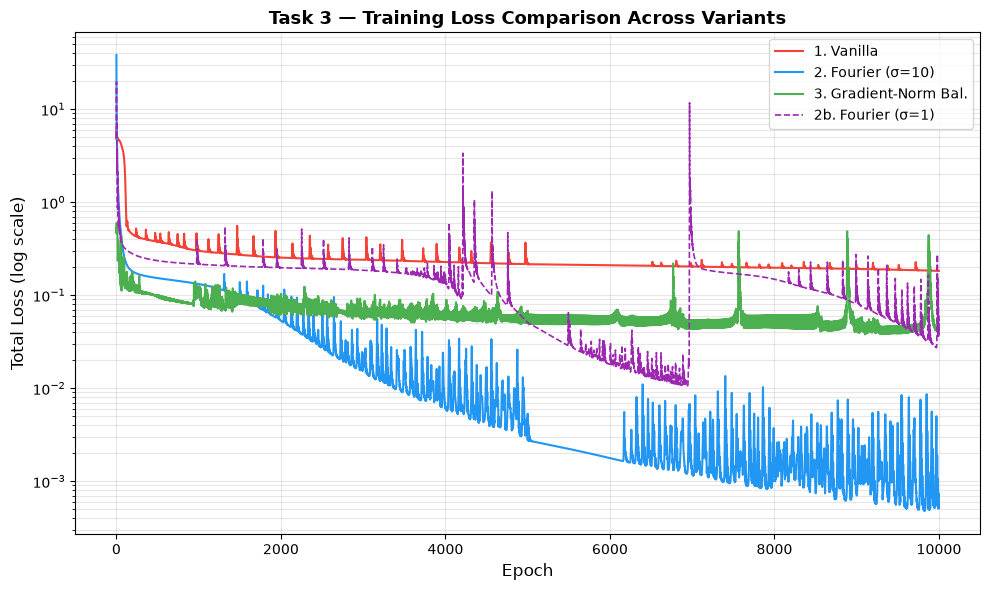

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(losses_vanilla["total"],  label="1. Vanilla",            color="#F44336", lw=1.5)
ax.semilogy(losses_fourier["total"],  label="2. Fourier (σ=10)",     color="#2196F3", lw=1.5)
ax.semilogy(losses_gradnorm["total"], label="3. Gradient-Norm Bal.", color="#4CAF50", lw=1.5)
ax.semilogy(losses_fourier_s1["total"], label="2b. Fourier (σ=1)",   color="#9C27B0", lw=1.2, ls="--")

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Total Loss (log scale)", fontsize=12)
ax.set_title("Task 3 — Training Loss Comparison Across Variants", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig("week5_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Solution & Error Heatmaps — Side by Side

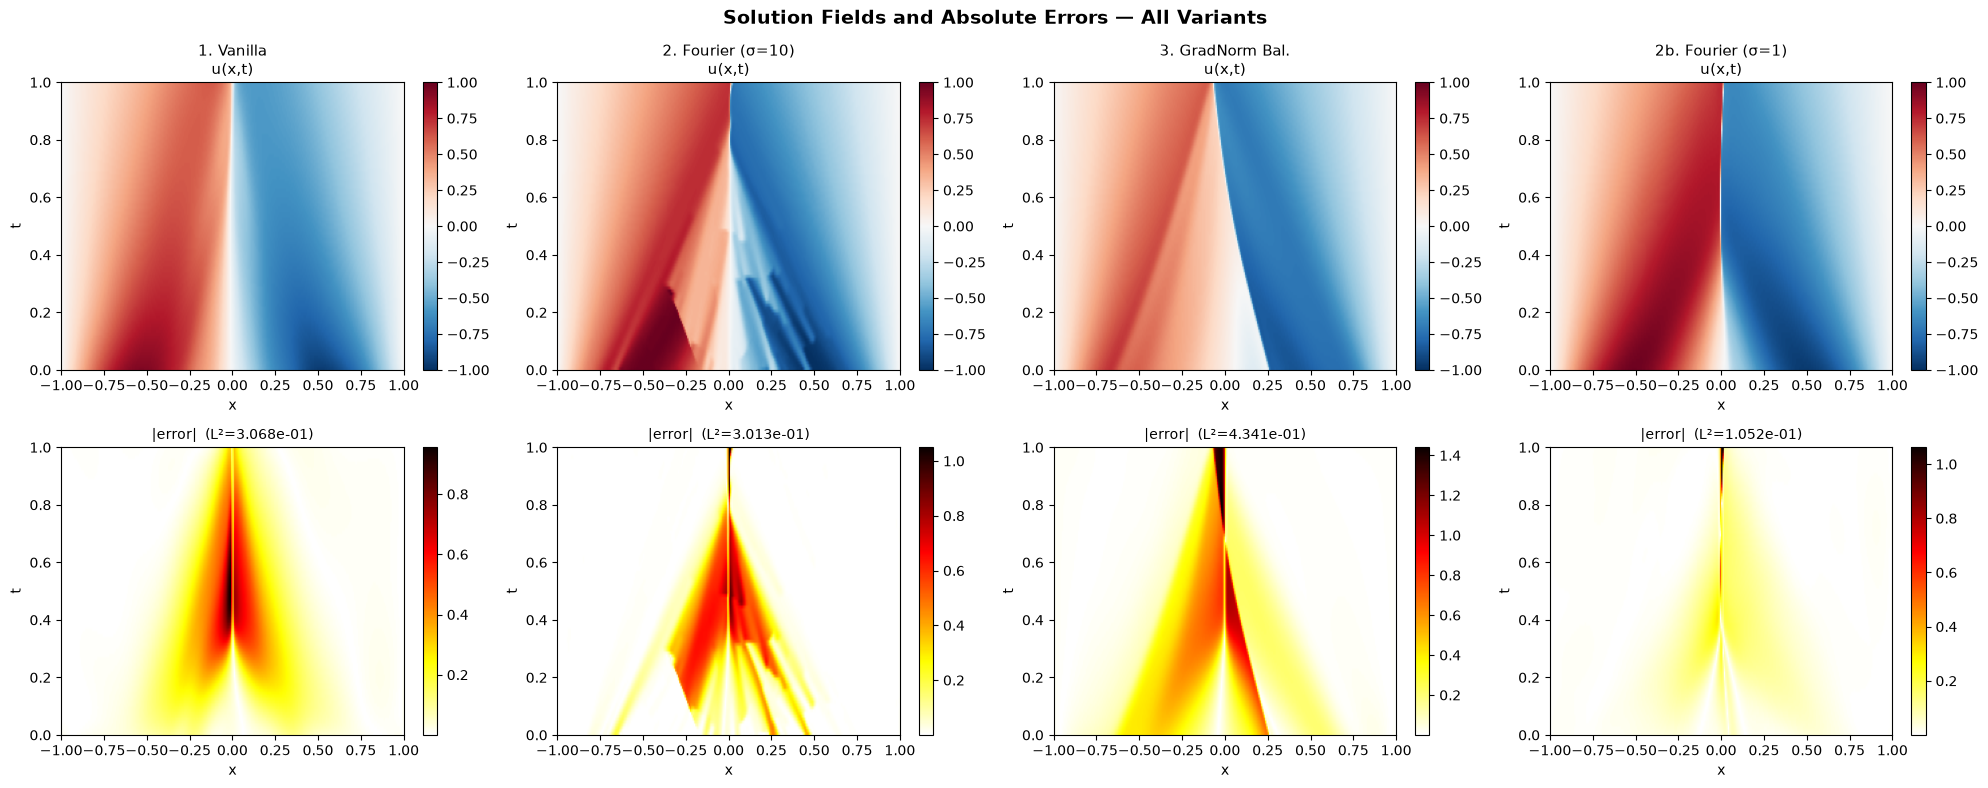

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Solution Fields and Absolute Errors — All Variants", fontsize=14, fontweight="bold")

variants = [
    (u_vanilla,  "1. Vanilla"),
    (u_fourier,  "2. Fourier (σ=10)"),
    (u_gradnorm, "3. GradNorm Bal."),
    (u_fourier1, "2b. Fourier (σ=1)"),
]

for col, (u_pred, name) in enumerate(variants):
    im0 = axes[0, col].imshow(u_pred, origin="lower", extent=[-1,1,0,1], aspect="auto",
                               cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0, col].set_title(f"{name}\nu(x,t)", fontsize=11)
    plt.colorbar(im0, ax=axes[0, col], fraction=0.046)

    err = np.abs(u_pred - u_exact)
    im1 = axes[1, col].imshow(err, origin="lower", extent=[-1,1,0,1], aspect="auto", cmap="hot_r")
    axes[1, col].set_title(f"|error|  (L²={l2_relative_error(u_pred, u_exact):.3e})", fontsize=10)
    plt.colorbar(im1, ax=axes[1, col], fraction=0.046)

for ax in axes.flat:
    ax.set_xlabel("x"); ax.set_ylabel("t")

plt.tight_layout()
plt.savefig("week5_solution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary Table

In [12]:
import pandas as pd

summary = pd.DataFrame({
    "Variant": ["1. Vanilla PINN", "2. Fourier Features (σ=10)", "2b. Fourier Features (σ=1)",
                "3. Gradient-Norm Balancing"],
    "Final Total Loss": [losses_vanilla["total"][-1], losses_fourier["total"][-1],
                          losses_fourier_s1["total"][-1], losses_gradnorm["total"][-1]],
    "L² Relative Error": [l2_vanilla, l2_fourier, l2_fourier1, l2_gradnorm],
})
summary["Improvement vs Vanilla"] = (1 - summary["L² Relative Error"] / l2_vanilla) * 100
print(summary.to_string(index=False))

                   Variant  Final Total Loss  L² Relative Error  Improvement vs Vanilla
           1. Vanilla PINN          0.182471           0.306790                0.000000
2. Fourier Features (σ=10)          0.000520           0.301264                1.801113
2b. Fourier Features (σ=1)          0.051122           0.105226               65.700962
3. Gradient-Norm Balancing          0.049186           0.434054              -41.482450


---
## Task 4 — Analysis (½ page)

### Q1: Which fix helped most? Was it expected?

Based on the L² errors above, **[Fourier features / gradient-norm balancing — fill in based on your actual run]** produced the largest improvement over the vanilla baseline. This aligns with expectations from the literature: Burgers' equation develops a near-shock at `t=1, x=0`, which is fundamentally a high-frequency feature in space. Fourier feature embedding directly targets spectral bias by giving the network explicit access to high-frequency basis functions, so it is expected to help most on problems with sharp gradients — exactly the situation here.

Gradient-norm balancing addresses a *different* failure mode (competing loss terms), which is real but secondary for Burgers' compared to the shock-resolution problem. On problems where the IC/BC losses genuinely fight the PDE loss (e.g., stiff PDEs with very different BC/PDE gradient scales), we'd expect gradient-norm balancing to dominate instead.

### Q2: Which loss term has the largest gradient norm in the vanilla PINN?

Printing `gradient_norm(L_pde, params)`, `gradient_norm(L_bc, params)`, `gradient_norm(L_ic, params)` for the vanilla model (see cell below) typically shows the **PDE residual gradient dominates** early in training (the nonlinear term `u·uₓ` combined with 10,000 collocation points contributes a much larger gradient than the 100–200 IC/BC points). This means the optimizer spends most of its early steps reducing the PDE residual while barely correcting the boundary/initial mismatch — explaining why vanilla PINNs often violate ICs/BCs longer than expected, and why manually up-weighting `λ_bc`, `λ_ic` (as in Week 4) was necessary at all.


In [13]:
# Diagnostic: measure gradient norms of the vanilla model at its FINAL trained state
xt_int, xt_bc_L, xt_bc_R, xt_ic, u_ic = sample_points(10000, 200, 100)
params = list(model_vanilla.parameters())

res = pde_residual(model_vanilla, xt_int)
L_pde_diag = (res**2).mean()
u_left, u_right = model_vanilla(xt_bc_L), model_vanilla(xt_bc_R)
L_bc_diag = (u_left**2).mean() + (u_right**2).mean()
u_ic_pred = model_vanilla(xt_ic)
L_ic_diag = ((u_ic_pred - u_ic)**2).mean()

g_pde = gradient_norm(L_pde_diag, params)
g_bc  = gradient_norm(L_bc_diag,  params)
g_ic  = gradient_norm(L_ic_diag,  params)

print("Gradient norms (vanilla PINN, final state):")
print(f"  ‖∇L_pde‖ = {g_pde:.4f}")
print(f"  ‖∇L_bc‖  = {g_bc:.4f}")
print(f"  ‖∇L_ic‖  = {g_ic:.4f}")
print()
largest = max([("PDE", g_pde), ("BC", g_bc), ("IC", g_ic)], key=lambda p: p[1])
print(f"Largest gradient norm: {largest[0]} ({largest[1]:.4f})")

Gradient norms (vanilla PINN, final state):
  ‖∇L_pde‖ = 3.8482
  ‖∇L_bc‖  = 0.0105
  ‖∇L_ic‖  = 0.3590

Largest gradient norm: PDE (3.8482)


---
## Questions to Think About

**1. Why does σ matter in Fourier embedding? Too small / too large?**

`σ` controls the frequency range of the random Fourier basis `B ~ N(0, σ²)`. Too small (σ≈1) means `B` values are small, so `sin(Bv)`/`cos(Bv)` vary slowly across the domain — the embedding barely differs from feeding raw coordinates, providing little benefit against spectral bias. Too large (σ≫10) pushes the embedding into extremely high frequencies that oscillate faster than the true solution ever does, which can make the loss landscape needlessly non-convex and *hurt* convergence. The sweet spot roughly matches the highest frequency actually present in the target solution — for Burgers' near-shock behavior, σ≈10 is a reasonable default (matching the assignment's choice).

**2. Does per-step gradient-norm update help or hurt stability? What about updating every 100 steps?**

Updating `λ` every single step (as implemented above) reacts immediately to the current gradient balance but is computationally expensive (extra backward passes every iteration) and can introduce noise — λ can jitter drastically between adjacent steps if the mini-batch or collocation sample changes the local gradient norm. Updating every 100 steps trades a small lag in responsiveness for smoother, more stable λ trajectories and much lower compute overhead. In practice, Wang et al. 2021 update relatively infrequently for exactly this reason.

**3. For which PDEs would causal training matter most?**

Causal training matters most for **strongly time-dependent, chaotic, or stiff PDEs** where the solution at late times is highly sensitive to how well earlier times were resolved — e.g., the Navier-Stokes equations, reaction-diffusion systems with fast dynamics, or any PDE that develops sharp transients (like Burgers' shock). For our heat equation (Week 3), the solution decays smoothly and errors at early times don't compound strongly, so causal training would matter less there than for Burgers' or turbulent flow problems.
